In [1]:
from bs4 import BeautifulSoup
from bs4 import MarkupResemblesLocatorWarning
import warnings

warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
soup = BeautifulSoup("https://www.worldometers.info/world-population/", 'html.parser')


In [2]:
import requests
data = requests.get(soup)
print(data)


<Response [200]>


In [3]:
raw_data = BeautifulSoup(data.text,"lxml")

In [4]:
raw_data.title.text

'World Population Clock: 8.3 Billion People (LIVE, 2026) - Worldometer'

In [5]:
table = raw_data.find("table")
                     

In [24]:
rows=table.find_all("tr")

for row in rows:
    print(row.get_text(" ",strip=True))

Year (July 1) Population Yearly % Change Yearly Change Median Age Fertility Rate Density (P/KmÂ²)
2026 8,300,678,395 0.84% 69,065,325 31.1 2.23 56
2025 8,231,613,070 0.85% 69,640,498 30.9 2.24 55
2024 8,161,972,572 0.87% 70,237,642 30.6 2.25 55
2023 8,091,734,930 0.88% 70,327,738 30.4 2.25 54
2022 8,021,407,192 0.84% 66,958,801 30.1 2.27 54
2021 7,954,448,391 0.86% 67,447,099 29.8 2.29 53
2020 7,887,001,292 1.09% 83,301,884 29.6 2.32 53
2015 7,470,491,872 1.25% 89,751,945 28.3 2.54 50
2010 7,021,732,148 1.29% 86,952,403 27.2 2.6 47
2005 6,586,970,132 1.31% 83,053,428 26.1 2.63 44
2000 6,171,702,993 1.39% 82,564,802 25.1 2.75 41
1995 5,758,878,982 1.57% 86,215,174 24 2.89 39
1990 5,327,803,110 1.82% 91,771,929 22.9 3.31 36
1985 4,868,943,465 1.83% 84,267,446 22 3.52 33
1980 4,447,606,236 1.79% 75,374,192 21.5 3.74 30
1975 4,070,735,277 1.96% 75,210,297 20.7 4.08 27
1970 3,694,683,794 2.07% 72,030,018 20.3 4.83 25
1965 3,334,533,703 2.03% 63,812,562 20.8 5.07 22
1960 3,015,470,894 1.93% 

In [28]:
import io
import pandas as pd
import requests

# Define headers to mimic a browser request
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# Target URL
url = "https://www.worldometers.info/world-population/"

# Fetch the page content
data = requests.get(url, headers=headers)
print(f"website Response Code: {data.status_code}(200 mens success)")

# Parse HTML tables into a list of DataFrames
df_list = pd.read_html(io.StringIO(data.text), flavor='lxml')
df=df_list[0]

# Print the results
print(f"Success! Found {len(df)} tables.")

website Response Code: 200(200 mens success)
Success! Found 20 tables.


In [32]:
df.to_csv("world_population_historical.csv", index=False)
print("success your csv file has been saved in notebook folder.")

success your csv file has been saved in notebook folder.


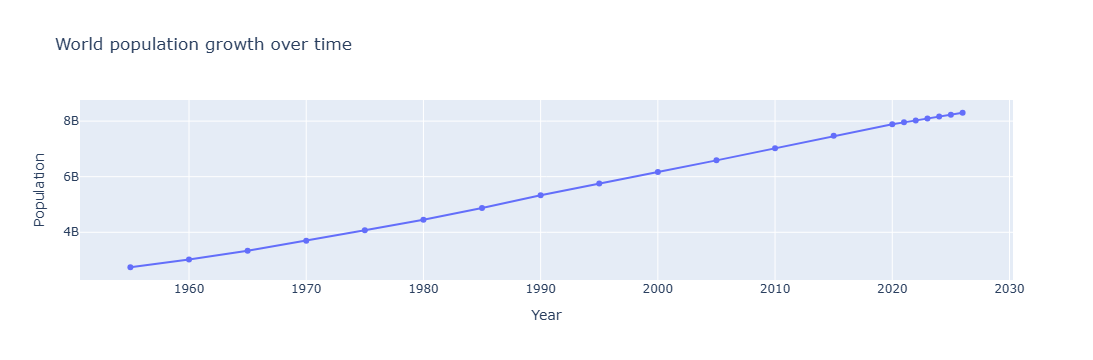

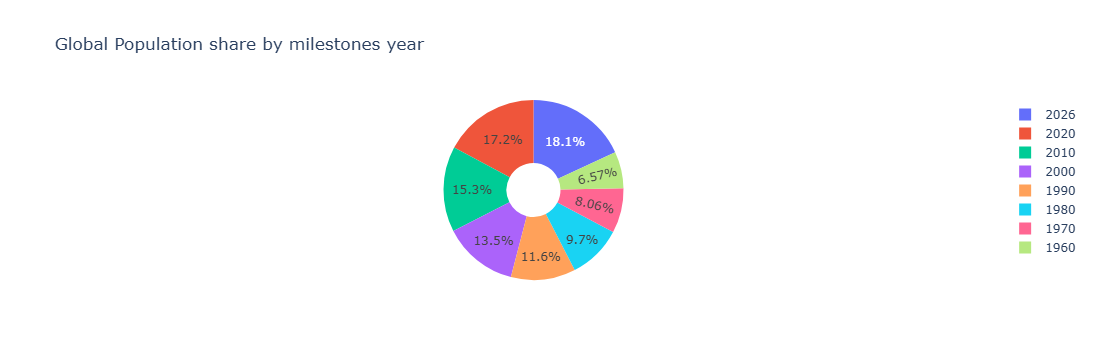

In [49]:
import plotly .graph_objects as go
import pandas as pd
df['Clean_Population']=df['Population'].astype(str).str.replace(',', '').astype(float)
df['Clean_Year']=df['Year (July 1)'].astype(str).str.extract(r'(\d{4})').astype(int)

df_sorted=df.sort_values('Clean_Year')
line_fig=go.Figure()
line_fig.add_trace(go.Scatter(
    x=df_sorted['Clean_Year'],
    y=df_sorted['Clean_Population'],
    mode="lines+markers",
    name="population"
))
line_fig.update_layout(
    title='World population growth over time',
    xaxis_title="Year",
    yaxis_title="Population"
)
line_fig.show()

pie_years=[1960,1970,1980,1990,2000,2010,2020,2026]
df_pie=df_sorted[df_sorted['Clean_Year'].isin(pie_years)]
pie_fig=go.Figure(data=[go.Pie(
    labels=df_pie['Clean_Year'],
    values = df_pie['Clean_Population'],
    hole=0.3
)])
pie_fig.update_layout(title='Global Population share by milestones year')
pie_fig.show()